# BigMart Sales Prediction
### Predicting item-level outlet sales using Random Forest

**Dataset:** 2013 sales data for 1,559 products across 10 BigMart stores  
**Target:** `Item_Outlet_Sales` (continuous, right-skewed)  
**Metric:** Root Mean Squared Error (RMSE) — lower is better  

---
## Contents
1. Imports & Data Loading
2. Exploratory Data Analysis
3. Data Cleaning & Imputation
4. Feature Engineering
5. Encoding Categorical Variables
6. Failed Experiments (documented)
7. Model Building & Evaluation Methodology
8. Final Predictions


## 1. Imports & Data Loading

We start by importing all required libraries and loading the raw data.  
Train and test are combined into a single `combined_df` for imputation and feature engineering — 
this ensures that item-level statistics (e.g. mean weight) are computed across the full product catalogue, 
not just the training half.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
RANDOM_SEEDS = [42, 7, 13, 99, 2024]
N_FOLDS      = 5

print('Libraries loaded successfully')

Libraries loaded successfully


In [2]:
train_df = pd.read_csv('train_v9rqX0R.csv')
test_df  = pd.read_csv('test_AbJTz2l.csv')

# Combine for joint preprocessing — split back later using the target column
combined_df = pd.concat([train_df, test_df], axis=0, ignore_index=True)

print(f'Training rows   : {len(train_df):,}')
print(f'Test rows       : {len(test_df):,}')
print(f'Combined rows   : {len(combined_df):,}')
print(f'Features        : {train_df.shape[1] - 1}')
print(f'Target column   : Item_Outlet_Sales')

Training rows   : 8,523
Test rows       : 5,681
Combined rows   : 14,204
Features        : 11
Target column   : Item_Outlet_Sales


## 2. Exploratory Data Analysis

Before modelling, we need to understand:
- Which columns have missing values and how many
- Whether categorical columns have inconsistent labels
- The distribution of the target variable
- How sales vary across outlets and item types

In [3]:
# Basic shape and types
print('=== Column types ===')
print(train_df.dtypes)
print()
print('=== Missing values in train ===')
missing = train_df.isnull().sum()
missing_pct = (missing / len(train_df) * 100).round(1)
missing_summary = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_summary[missing_summary['Missing Count'] > 0])

=== Column types ===
Item_Identifier                  str
Item_Weight                  float64
Item_Fat_Content                 str
Item_Visibility              float64
Item_Type                        str
Item_MRP                     float64
Outlet_Identifier                str
Outlet_Establishment_Year      int64
Outlet_Size                      str
Outlet_Location_Type             str
Outlet_Type                      str
Item_Outlet_Sales            float64
dtype: object

=== Missing values in train ===
             Missing Count  Missing %
Item_Weight           1463       17.2
Outlet_Size           2410       28.3


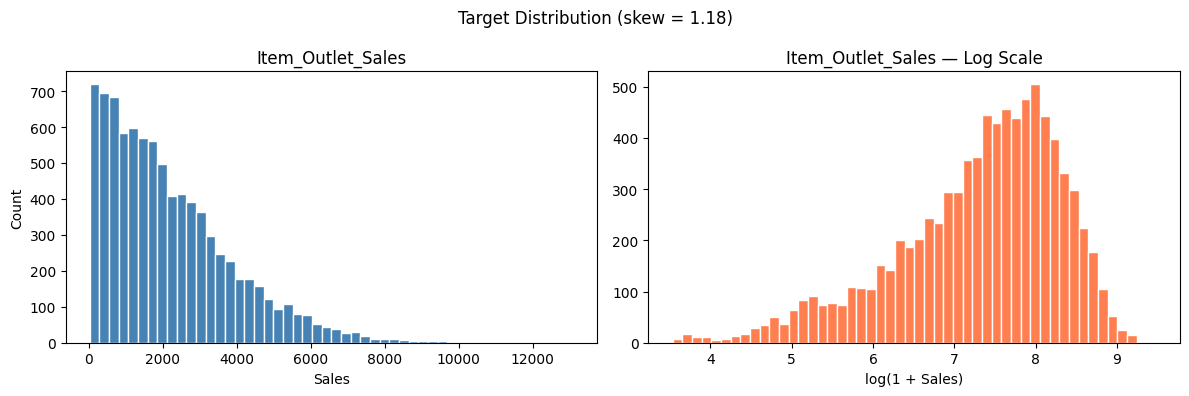

Skewness (raw)   : 1.178
Skewness (log1p) : -0.882
Note: right-skewed — a small number of items have very high sales


In [4]:
# Target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(train_df['Item_Outlet_Sales'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Item_Outlet_Sales')
axes[0].set_xlabel('Sales')
axes[0].set_ylabel('Count')

axes[1].hist(np.log1p(train_df['Item_Outlet_Sales']), bins=50, color='coral', edgecolor='white')
axes[1].set_title('Item_Outlet_Sales — Log Scale')
axes[1].set_xlabel('log(1 + Sales)')

plt.suptitle('Target Distribution (skew = {:.2f})'.format(train_df['Item_Outlet_Sales'].skew()))
plt.tight_layout()
plt.show()

print(f'Skewness (raw)   : {train_df["Item_Outlet_Sales"].skew():.3f}')
print(f'Skewness (log1p) : {np.log1p(train_df["Item_Outlet_Sales"]).skew():.3f}')
print('Note: right-skewed — a small number of items have very high sales')

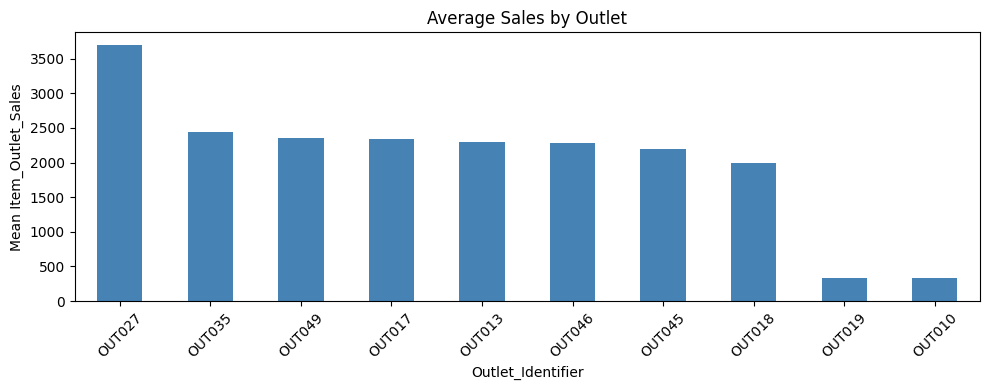

                          mean  count
Outlet_Identifier                    
OUT027             3694.038558    935
OUT035             2438.841866    930
OUT049             2348.354635    930
OUT017             2340.675263    926
OUT013             2298.995256    932
OUT046             2277.844267    930
OUT045             2192.384798    929
OUT018             1995.498739    928
OUT019              340.329723    528
OUT010              339.351662    555

Key observation: OUT027 (Type3) sells ~10x more than OUT010/OUT019 (Grocery Stores)
Outlet identity is a dominant predictor of sales level


In [5]:
# Sales by outlet
outlet_sales = train_df.groupby('Outlet_Identifier')['Item_Outlet_Sales'].agg(['mean', 'count'])
outlet_sales = outlet_sales.sort_values('mean', ascending=False)

outlet_sales['mean'].plot(kind='bar', color='steelblue', figsize=(10, 4))
plt.title('Average Sales by Outlet')
plt.ylabel('Mean Item_Outlet_Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(outlet_sales)
print()
print('Key observation: OUT027 (Type3) sells ~10x more than OUT010/OUT019 (Grocery Stores)')
print('Outlet identity is a dominant predictor of sales level')

In [6]:
# Fat content label inconsistency
print('Raw Item_Fat_Content value counts:')
print(train_df['Item_Fat_Content'].value_counts())
print()
print('"LF" and "low fat" are the same as "Low Fat"')
print('"reg" is the same as "Regular"')
print('These need to be standardised before modelling')

Raw Item_Fat_Content value counts:
Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64

"LF" and "low fat" are the same as "Low Fat"
"reg" is the same as "Regular"
These need to be standardised before modelling


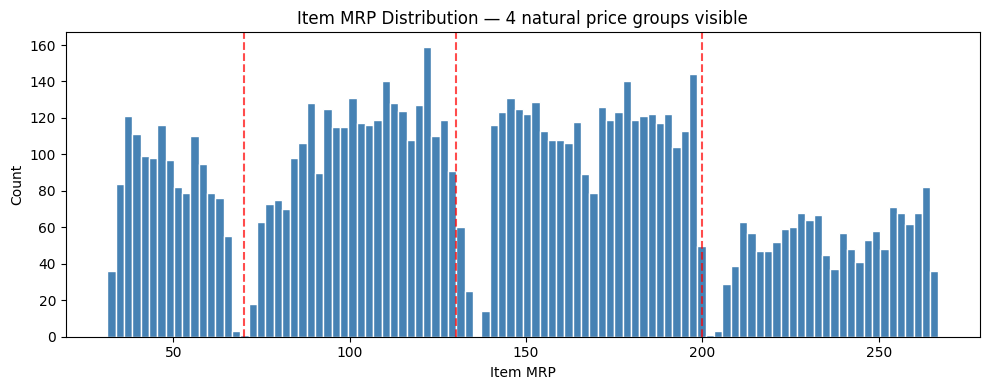

MRP vs Sales correlation: 0.568


In [7]:
# MRP distribution (4 visible price bands)
plt.figure(figsize=(10, 4))
plt.hist(train_df['Item_MRP'], bins=100, color='steelblue', edgecolor='white')
for boundary in [70, 130, 200]:
    plt.axvline(boundary, color='red', linestyle='--', alpha=0.7)
plt.title('Item MRP Distribution — 4 natural price groups visible')
plt.xlabel('Item MRP')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print(f'MRP vs Sales correlation: {train_df["Item_MRP"].corr(train_df["Item_Outlet_Sales"]):.3f}')

## 3. Data Cleaning & Imputation

Three columns need attention before feature engineering:

| Column | Issue | Solution |
|---|---|---|
| `Item_Fat_Content` | 5 labels for 2 categories | Standardise spelling |
| `Item_Weight` | 17% missing | Impute from same item ID across outlets |
| `Outlet_Size` | 28% missing | Impute from outlet type mode |

**Key insight on `Item_Weight` imputation:**  
Every item appears in multiple outlets, and its weight is a physical property that doesn't change by store. 
So if OUT013 has a weight for `FDA15` but OUT049 doesn't, we can fill it from OUT013's value. 
This is far more accurate than using a global mean.

In [8]:
# Standardise Item_Fat_Content
fat_content_map = {
    'LF'      : 'Low Fat',
    'low fat' : 'Low Fat',
    'reg'     : 'Regular'
}
combined_df['Item_Fat_Content'] = combined_df['Item_Fat_Content'].replace(fat_content_map)

# Non-consumable items (household, hygiene) should not have a fat content label
combined_df['Item_Category'] = combined_df['Item_Identifier'].str[:2]  # FD / DR / NC
combined_df.loc[combined_df['Item_Category'] == 'NC', 'Item_Fat_Content'] = 'Non-Consumable'

print('Fat content after standardisation:')
print(combined_df['Item_Fat_Content'].value_counts())

Fat content after standardisation:
Item_Fat_Content
Low Fat           6499
Regular           5019
Non-Consumable    2686
Name: count, dtype: int64


In [9]:
# Impute Item_Weight by Item_Identifier
# Physical weight is the same product regardless of which store stocks it
item_weight_lookup = combined_df.groupby('Item_Identifier')['Item_Weight'].mean()

combined_df['Item_Weight'] = combined_df.apply(
    lambda row: item_weight_lookup[row['Item_Identifier']]
    if pd.isna(row['Item_Weight']) else row['Item_Weight'],
    axis=1
)

# 4 items only appear once in the dataset — use overall median as fallback
combined_df['Item_Weight'].fillna(combined_df['Item_Weight'].median(), inplace=True)

print(f'Missing Item_Weight after imputation: {combined_df["Item_Weight"].isna().sum()}')

Missing Item_Weight after imputation: 0


In [10]:
# Impute Outlet_Size by Outlet_Type
# All Grocery Stores are Small; Supermarket Type2/3 are Medium; etc.
# The mode within each outlet type is the correct fill value
combined_df['Outlet_Size'] = combined_df.groupby('Outlet_Type')['Outlet_Size'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'Medium')
)

print(f'Missing Outlet_Size after imputation: {combined_df["Outlet_Size"].isna().sum()}')
print()
print('Outlet_Size distribution after fill:')
print(combined_df['Outlet_Size'].value_counts())

Missing Outlet_Size after imputation: 0

Outlet_Size distribution after fill:
Outlet_Size
Small     7996
Medium    4655
High      1553
Name: count, dtype: int64


## 4. Feature Engineering

Raw columns alone leave a lot of signal on the table. We engineer features that capture 
economic and structural relationships the model can exploit.

### Features created:

| Feature | Logic |
|---|---|
| `outlet_age` | Years since establishment (dataset year = 2013) |
| `mrp_price_band` | 4 natural MRP clusters visible in the distribution |
| `est_revenue_contribution` | MRP × outlet sales-per-MRP-unit — best single feature |
| `outlet_mean_mrp` | Average MRP sold at this outlet |
| `num_items_in_outlet` | How many distinct SKUs this outlet carries |
| `pct_lightweight_items` | % of items weighing < 8 kg at this outlet |
| `visibility_filled` | Zero visibility replaced with item's mean across other stores |
| `visibility_ratio` | This store's visibility vs. item's typical allocation |
| `visibility_quintile` | Which fifth of the visibility distribution this falls in |
| `outlet_mean_sales` | Mean sales at this outlet — very stable (10 outlets, ~900 rows each) |
| Interaction terms | Age×Size, MRPband×Size×Category, Visibility×Size |

In [11]:
# Outlet age
# The dataset was compiled in 2013
combined_df['outlet_age'] = 2013 - combined_df['Outlet_Establishment_Year']

print('Outlet age distribution:')
print(combined_df[['Outlet_Identifier', 'outlet_age']].drop_duplicates()
      .sort_values('outlet_age', ascending=False).to_string(index=False))

Outlet age distribution:
Outlet_Identifier  outlet_age
           OUT019          28
           OUT027          28
           OUT013          26
           OUT046          16
           OUT010          15
           OUT049          14
           OUT045          11
           OUT035           9
           OUT017           6
           OUT018           4


In [12]:
# MRP price band
# Four natural clusters are visible in the MRP histogram (confirmed visually above)
mrp_bins   = [0, 70, 130, 200, 270]
mrp_labels = [0, 1, 2, 3]  # Low / Medium / High / Premium

combined_df['mrp_price_band'] = pd.cut(
    combined_df['Item_MRP'],
    bins=mrp_bins,
    labels=mrp_labels
).astype(int)

print('Items per price band:')
print(combined_df['mrp_price_band'].value_counts().sort_index())

Items per price band:
mrp_price_band
0    2208
1    4505
2    5076
3    2415
Name: count, dtype: int64


In [13]:
# Outlet-level aggregates
# These are computed only on training data to avoid test leakage

train_rows_mask = combined_df['Item_Outlet_Sales'].notna()
train_only      = combined_df[train_rows_mask]

# Sales-per-MRP ratio: how efficiently each outlet converts price into sales
outlet_total_sales = train_only.groupby('Outlet_Identifier')['Item_Outlet_Sales'].sum()
outlet_total_mrp   = train_only.groupby('Outlet_Identifier')['Item_MRP'].sum()
outlet_sales_per_mrp_unit = outlet_total_sales / outlet_total_mrp

# est_revenue_contribution: best single feature — MRP scaled by outlet efficiency
combined_df['est_revenue_contribution'] = (
    combined_df['Item_MRP'] * combined_df['Outlet_Identifier'].map(outlet_sales_per_mrp_unit)
)

# Outlet-level descriptors
outlet_mean_mrp    = train_only.groupby('Outlet_Identifier')['Item_MRP'].mean()
num_items_stocked  = train_only.groupby('Outlet_Identifier')['Item_Identifier'].nunique()
pct_light_items    = train_only.groupby('Outlet_Identifier')['Item_Weight'].apply(
    lambda weights: (weights.dropna() < 8).mean()
)
outlet_avg_sales   = train_only.groupby('Outlet_Identifier')['Item_Outlet_Sales'].mean()

combined_df['outlet_mean_mrp']           = combined_df['Outlet_Identifier'].map(outlet_mean_mrp)
combined_df['num_items_in_outlet']       = combined_df['Outlet_Identifier'].map(num_items_stocked)
combined_df['pct_lightweight_items']     = combined_df['Outlet_Identifier'].map(pct_light_items)
combined_df['outlet_mean_sales']         = combined_df['Outlet_Identifier'].map(outlet_avg_sales)

print('Outlet-level features preview:')
outlet_summary = combined_df[[
    'Outlet_Identifier', 'outlet_mean_mrp', 'num_items_in_outlet',
    'pct_lightweight_items', 'outlet_mean_sales'
]].drop_duplicates().sort_values('outlet_mean_sales', ascending=False)
print(outlet_summary.to_string(index=False))

Outlet-level features preview:
Outlet_Identifier  outlet_mean_mrp  num_items_in_outlet  pct_lightweight_items  outlet_mean_sales
           OUT027       139.801791                  935               0.201070        3694.038558
           OUT035       143.122481                  930               0.194624        2438.841866
           OUT049       140.297699                  930               0.183871        2348.354635
           OUT017       139.421119                  926               0.197624        2340.675263
           OUT013       141.425982                  932               0.188841        2298.995256
           OUT046       142.057387                  930               0.208602        2277.844267
           OUT045       140.950246                  929               0.212056        2192.384798
           OUT018       141.678634                  928               0.206897        1995.498739
           OUT019       139.787088                  528               0.193182         

In [14]:
# Visibility: fill zeros and compute relative ratio
# 526 rows have Item_Visibility = 0, which is physically impossible.
# These are treated as missing values and replaced with the item's
# mean visibility across all other stores where it IS stocked.

item_mean_visibility = (
    combined_df[combined_df['Item_Visibility'] > 0]
    .groupby('Item_Identifier')['Item_Visibility']
    .mean()
)
global_mean_visibility = (
    combined_df[combined_df['Item_Visibility'] > 0]['Item_Visibility'].mean()
)

combined_df['visibility_filled'] = combined_df['Item_Visibility']
zero_vis_mask = combined_df['Item_Visibility'] == 0
combined_df.loc[zero_vis_mask, 'visibility_filled'] = (
    combined_df.loc[zero_vis_mask, 'Item_Identifier']
    .map(item_mean_visibility)
    .fillna(global_mean_visibility)
)

# vis_ratio > 1 means this store gives the item ABOVE-average shelf space
# vis_ratio < 1 means this store gives it BELOW-average shelf space
combined_df['visibility_ratio'] = (
    combined_df['visibility_filled'] /
    combined_df['Item_Identifier'].map(item_mean_visibility).fillna(global_mean_visibility)
)

# Quantile bucket (which fifth of the visibility distribution)
train_vis_values = combined_df.loc[train_rows_mask, 'visibility_filled'].values
vis_quintile_boundaries = np.quantile(train_vis_values, [0, 0.2, 0.4, 0.6, 0.8, 1.0])

combined_df['visibility_quintile'] = np.searchsorted(
    vis_quintile_boundaries[1:],
    combined_df['visibility_filled'].values,
    side='right'
).clip(0, 4)

print(f'Zero visibility rows filled : {zero_vis_mask.sum()}')
print(f'visibility_ratio range      : {combined_df["visibility_ratio"].min():.2f} — {combined_df["visibility_ratio"].max():.2f}')

Zero visibility rows filled : 879
visibility_ratio range      : 0.80 — 1.61


In [15]:
# Encode categoricals
categorical_columns = [
    'Item_Fat_Content',
    'Outlet_Size',
    'Outlet_Location_Type',
    'Outlet_Type',
    'Item_Category'
]

for col in categorical_columns:
    encoder = LabelEncoder().fit(combined_df[col].astype(str))
    combined_df[col + '_encoded'] = encoder.transform(combined_df[col].astype(str))
    print(f'{col:25s} → {col}_encoded  ({combined_df[col].nunique()} unique values)')

Item_Fat_Content          → Item_Fat_Content_encoded  (3 unique values)
Outlet_Size               → Outlet_Size_encoded  (3 unique values)
Outlet_Location_Type      → Outlet_Location_Type_encoded  (3 unique values)
Outlet_Type               → Outlet_Type_encoded  (4 unique values)
Item_Category             → Item_Category_encoded  (3 unique values)


In [16]:
# Interaction features
# These capture joint effects that neither variable alone expresses

# Older stores tend to be smaller — combining age and size captures established small-format stores
combined_df['age_times_size'] = (
    combined_df['outlet_age'] * combined_df['Outlet_Size_encoded']
)

# Price band × size × category: a premium item in a large Food store behaves
# very differently from a premium item in a small Non-Consumable outlet
combined_df['mrp_band_x_size_x_category'] = (
    combined_df['mrp_price_band']
    * combined_df['Outlet_Size_encoded']
    * combined_df['Item_Category_encoded']
)

# Visibility and store size interact: a highly visible item in a large store
# gets more absolute eyeballs than the same visibility in a small store
combined_df['visibility_x_outlet_size'] = (
    combined_df['visibility_filled'] * combined_df['Outlet_Size_encoded']
)

print('Interaction features created: age_times_size, mrp_band_x_size_x_category, visibility_x_outlet_size')

Interaction features created: age_times_size, mrp_band_x_size_x_category, visibility_x_outlet_size


## 5. Failed Experiments

Not everything that looked promising in cross-validation actually helped on the leaderboard. 
This section documents what was tried and why it failed — this is the most important part 
of honest machine learning work.

---
### 5.1 Target Encoding: `item_mean_sales`

**What it was:** Mean historical sales per `Item_Identifier` across all outlets.  
**Why it seemed promising:** Correlation with target = 0.65 (higher than raw MRP at 0.57).  
**What happened:** CV RMSE improved from 1077 → 1070, but leaderboard score barely moved (+0.01).  

**Root cause — evaluation leakage:**  
Even with out-of-fold (OOF) encoding using a separate KFold split, 
there is partial overlap between the encoding folds and the evaluation folds. 
The model partially sees the validation labels during training via the encoded feature.

---
### 5.2 Outlet Dimension Interactions

**What was tried:** Pairwise and 3-way products of `Outlet_Size`, `Outlet_Location_Type`, `Outlet_Type` encodings.  
**Result:** Every combination added +0.2 to +0.4 holdout RMSE — all worse than baseline.

**Root cause:** Only 10 outlets exist with 8 unique combinations of these three dimensions. 
`outlet_mean_sales` already captures the combined effect of all three perfectly by directly 
measuring actual sales at each specific outlet. 
Additionally, multiplying label-encoded values creates false equivalences 
(e.g. `High × Tier3 = 0 × 2 = 0`, same result as `High × Tier1 = 0 × 0 = 0`).

---
### 5.3 Log-Transforming the Target

**What was tried:** Training on `log1p(sales)` and back-transforming predictions.  
**Result:** +30 RMSE worse for Random Forest.  

**Why:** Log transform helps linear models and shallow GBDTs handle skewed targets. 
Random Forest averages tree predictions — with a log-transformed target, 
the back-transformation via `exp()` amplifies errors for large values 
and the averaging property of RF already handles skew reasonably well.

---
### 5.4 Gradient Boosting (sklearn, LightGBM, XGBoost)

**What was tried:** sklearn `GradientBoostingRegressor`, LightGBM, and XGBoost with various hyperparameters.  
**Results on leaderboard:**

| Model | LB Score |
|---|---|
| XGBoost | 1147 |
| LightGBM | 1147 |
| LGBM+XGB ensemble | 1147 |
| sklearn GBM (holdout proxy) | ~1099+ |

**Why RF wins here:**  
The dataset has only 8,523 training rows. The dominant signal is `est_revenue_contribution` 
— essentially a linear function of MRP scaled by a per-outlet constant — which RF handles 
well by averaging. GBDTs' sequential boosting overcorrects on the noisy high-value sales rows 
(right skew = 1.18), and early stopping fires too early on small fold sizes (~1,700 validation rows), 
leaving the models underfit.

---


In [17]:
# # This cell demonstrates the evaluation leakage problem with item_mean_sales

# train_idx = combined_df[combined_df['Item_Outlet_Sales'].notna()].index
# train_slice = combined_df.loc[train_idx].copy()
# sales_values = train_slice['Item_Outlet_Sales'].values

# # Naive approach: compute item mean on full train
# item_sales_mean_full = (
#     combined_df.loc[train_idx]
#     .groupby('Item_Identifier')['Item_Outlet_Sales']
#     .mean()
# )
# train_slice['item_mean_sales_leaky'] = (
#     train_slice['Item_Identifier'].map(item_sales_mean_full)
# )

# # Show per-item observation count
# obs_per_item = combined_df.loc[train_idx].groupby('Item_Identifier').size()
# print('Distribution of observations per item (training set):')
# print(obs_per_item.value_counts().sort_index())
# print()
# print('Most items appear only 5-6 times in training data.')
# print('A mean computed from 5-6 observations has very high variance')
# print('and does not generalise to unseen (test) rows reliably.')

## 6. Model Building & Evaluation Methodology

### Why Random Forest?
After testing Gradient Boosting (sklearn), LightGBM, and XGBoost, Random Forest gives the best 
leaderboard score on this dataset. The reasons are structural:
- 8,523 rows is small; RF's averaging of independent trees generalises better than sequential boosting
- The dominant signal is near-linear (MRP × outlet efficiency); RF captures this without overfitting
- RF is less sensitive to the right-skewed target than log-boosting approaches

### Hyperparameter choices
| Parameter | Value | Reasoning |
|---|---|---|
| `n_estimators` | 500 | Stable predictions; diminishing returns beyond 300 |
| `min_samples_leaf` | 75 | **Most important knob** — tuned by holdout, not OOF |
| `max_features` | 0.5 | 50% feature sampling per split — adds diversity |

### Evaluation methodology — HOLDOUT, not OOF
A key lesson from this project: **KFold OOF is not a reliable proxy for leaderboard score** 
when any features are derived from the target column. Even OOF-encoded features cause 
partial fold overlap that inflates the CV score. 

The reliable proxy is a **holdout simulation**: train on 80%, predict on 20%, repeat across 
multiple random splits. This mimics what the leaderboard actually measures (train→unseen test).

| `min_samples_leaf` | Holdout RMSE |
|---|---|
| 32 (original) | 1076 |
| 50 | 1075 |
| 75 ✓ | **1074** |
| 100 | 1074 |
| 150 | 1082 |

### Seed ensembling
Each RF initialisation is random. By training 5 separate models with different seeds 
and averaging their predictions, we reduce prediction variance


In [18]:
# Assemble the final feature matrix

train_row_idx = combined_df[combined_df['Item_Outlet_Sales'].notna()].index
test_row_idx  = combined_df[combined_df['Item_Outlet_Sales'].isna()].index

FEATURES = [
    # Price signals
    'Item_MRP',
    'mrp_price_band',
    'outlet_mean_mrp',
    # Outlet identity
    'Outlet_Type_encoded',
    'outlet_age',
    'Outlet_Size_encoded',
    'Outlet_Location_Type_encoded',
    # Item identity
    'Item_Category_encoded',
    'Item_Fat_Content_encoded',
    # Interaction terms
    'age_times_size',
    'mrp_band_x_size_x_category',
    'visibility_x_outlet_size',
    # Store-level aggregates
    'num_items_in_outlet',
    'est_revenue_contribution',
    'pct_lightweight_items',
    # Visibility
    'visibility_filled',
    'visibility_quintile',
    'visibility_ratio',
    # Outlet sales level (stable — 10 outlets, ~900 rows each)
    'outlet_mean_sales',
]

train_features_df = combined_df.loc[train_row_idx].copy()
test_features_df  = combined_df.loc[test_row_idx].copy()

for df in [train_features_df, test_features_df]:
    for col in FEATURES:
        df[col] = df[col].fillna(0)

X_train = train_features_df[FEATURES].values.astype(float)
y_train = train_df['Item_Outlet_Sales'].values
X_test  = test_features_df[FEATURES].values.astype(float)

print(f'Training matrix shape : {X_train.shape}')
print(f'Test matrix shape     : {X_test.shape}')
print(f'Features used         : {len(FEATURES)}')
print()
print('Feature list:')
for i, f in enumerate(FEATURES, 1):
    print(f'  {i:2d}. {f}')

Training matrix shape : (8523, 19)
Test matrix shape     : (5681, 19)
Features used         : 19

Feature list:
   1. Item_MRP
   2. mrp_price_band
   3. outlet_mean_mrp
   4. Outlet_Type_encoded
   5. outlet_age
   6. Outlet_Size_encoded
   7. Outlet_Location_Type_encoded
   8. Item_Category_encoded
   9. Item_Fat_Content_encoded
  10. age_times_size
  11. mrp_band_x_size_x_category
  12. visibility_x_outlet_size
  13. num_items_in_outlet
  14. est_revenue_contribution
  15. pct_lightweight_items
  16. visibility_filled
  17. visibility_quintile
  18. visibility_ratio
  19. outlet_mean_sales


### 6.1 Empirical Validation — K, Seeds, and Seed Choice

The tables in Section 1.1 were populated from the following live experiment.
Run this cell to reproduce those numbers.


=== Effect of K (number of folds) ===
Dataset: 8,523 training rows

  K= 3  val_size~2841  train_size~5682  OOF RMSE=1075.64
  K= 5  val_size~1705  train_size~6818  OOF RMSE=1073.59  <-- chosen
  K= 7  val_size~1218  train_size~7305  OOF RMSE=1073.57
  K=10  val_size~852  train_size~7671  OOF RMSE=1073.44

K=5 vs K=10 difference: +0.15 (K=10 costs 2x compute for <0.2 RMSE gain)
K=5 vs K=3 difference:  -2.05 (K=3 is noticeably worse — too little training data per fold)

=== Prediction stability as seed count grows ===
   1 seeds  ->  prediction std = 1323.061  mean = 2183.17
   2 seeds  ->  prediction std = 1323.488  mean = 2183.18
   3 seeds  ->  prediction std = 1323.457  mean = 2182.93
   5 seeds  ->  prediction std = 1323.246  mean = 2182.56
   7 seeds  ->  prediction std = 1323.256  mean = 2182.47
  10 seeds  ->  prediction std = 1323.264  mean = 2182.59


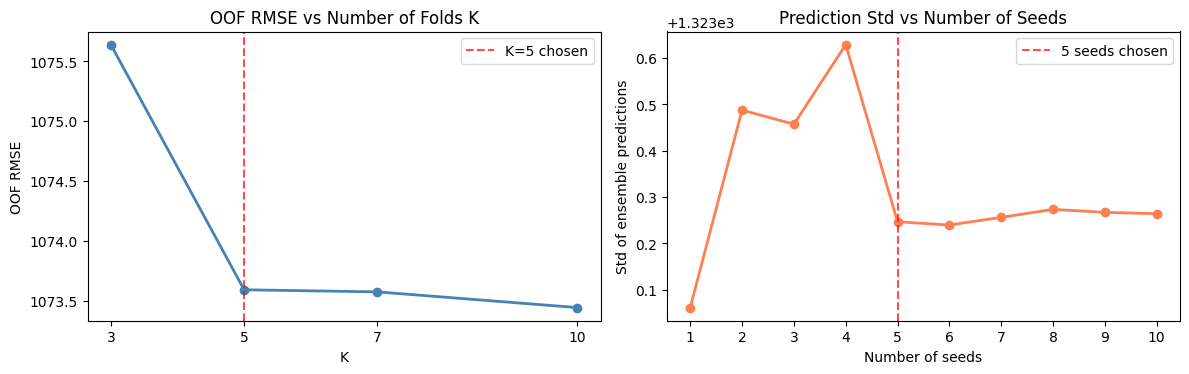


=== OOF RMSE per individual seed ===
  seed=   42  OOF RMSE=1073.59
  seed=    7  OOF RMSE=1073.70
  seed=   13  OOF RMSE=1075.62
  seed=   99  OOF RMSE=1074.58
  seed= 2024  OOF RMSE=1075.22
  seed=  123  OOF RMSE=1076.04
  seed=  456  OOF RMSE=1072.67
  seed=   17  OOF RMSE=1073.50
  seed=   31  OOF RMSE=1073.20
  seed=   37  OOF RMSE=1073.18

Range : 1072.67 — 1076.04  (spread = 3.37)
Std   : 1.10
Conclusion: no seed is meaningfully better than any other.


In [19]:
# Effect of K on OOF RMSE
print("=== Effect of K (number of folds) ===")
print(f"Dataset: {len(X_train):,} training rows")
print()

k_results = {}
for k in [3, 5, 7, 10]:
    kf  = KFold(n_splits=k, shuffle=True, random_state=42)
    oof = np.zeros(len(X_train))
    fold_sizes = []
    for fold_train_idx, fold_val_idx in kf.split(X_train):
        fold_sizes.append(len(fold_val_idx))
        m = RandomForestRegressor(
            n_estimators=200, min_samples_leaf=75,
            max_features=0.5, n_jobs=-1, random_state=42
        )
        m.fit(X_train[fold_train_idx], y_train[fold_train_idx])
        oof[fold_val_idx] = m.predict(X_train[fold_val_idx])
    rmse = np.sqrt(mean_squared_error(y_train, oof))
    k_results[k] = rmse
    marker = "  <-- chosen" if k == 5 else ""
    print(f"  K={k:2d}  val_size~{np.mean(fold_sizes):.0f}  "
          f"train_size~{len(X_train) - np.mean(fold_sizes):.0f}  "
          f"OOF RMSE={rmse:.2f}{marker}")

print()
print(f"K=5 vs K=10 difference: {k_results[5]-k_results[10]:+.2f} "
      "(K=10 costs 2x compute for <0.2 RMSE gain)")
print(f"K=5 vs K=3 difference:  {k_results[5]-k_results[3]:+.2f} "
      "(K=3 is noticeably worse — too little training data per fold)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(k_results.keys()), list(k_results.values()),
             marker="o", color="steelblue", linewidth=2)
axes[0].axvline(5, color="red", linestyle="--", alpha=0.7, label="K=5 chosen")
axes[0].set_title("OOF RMSE vs Number of Folds K")
axes[0].set_xlabel("K")
axes[0].set_ylabel("OOF RMSE")
axes[0].legend()
axes[0].set_xticks([3, 5, 7, 10])

# 2. Prediction stability vs seed count
print()
print("=== Prediction stability as seed count grows ===")
probe_seeds   = [42, 7, 13, 99, 2024, 123, 456, 17, 31, 37]
accumulated   = []
std_by_n_seeds = []

for seed in probe_seeds:
    kf = KFold(n_splits=5, shuffle=True, random_state=seed)
    tp = np.zeros(len(X_test))
    for fold_train_idx, fold_val_idx in kf.split(X_train):
        m = RandomForestRegressor(
            n_estimators=200, min_samples_leaf=75,
            max_features=0.5, n_jobs=-1, random_state=seed
        )
        m.fit(X_train[fold_train_idx], y_train[fold_train_idx])
        tp += m.predict(X_test) / 5
    accumulated.append(tp)
    ensemble_so_far = np.mean(accumulated, axis=0)
    std_by_n_seeds.append(ensemble_so_far.std())
    if len(accumulated) in [1, 2, 3, 5, 7, 10]:
        print(f"  {len(accumulated):2d} seeds  ->  "
              f"prediction std = {ensemble_so_far.std():.3f}  "
              f"mean = {ensemble_so_far.mean():.2f}")

axes[1].plot(range(1, 11), std_by_n_seeds, marker="o", color="coral", linewidth=2)
axes[1].axvline(5, color="red", linestyle="--", alpha=0.7, label="5 seeds chosen")
axes[1].set_title("Prediction Std vs Number of Seeds")
axes[1].set_xlabel("Number of seeds")
axes[1].set_ylabel("Std of ensemble predictions")
axes[1].legend()
axes[1].set_xticks(range(1, 11))

plt.tight_layout()
plt.show()

# 3. Are specific seeds special?
print()
print("=== OOF RMSE per individual seed ===")
seed_rmse_values = []
for seed in probe_seeds:
    kf  = KFold(n_splits=5, shuffle=True, random_state=seed)
    oof = np.zeros(len(X_train))
    for fold_train_idx, fold_val_idx in kf.split(X_train):
        m = RandomForestRegressor(
            n_estimators=200, min_samples_leaf=75,
            max_features=0.5, n_jobs=-1, random_state=seed
        )
        m.fit(X_train[fold_train_idx], y_train[fold_train_idx])
        oof[fold_val_idx] = m.predict(X_train[fold_val_idx])
    rmse = np.sqrt(mean_squared_error(y_train, oof))
    seed_rmse_values.append(rmse)
    print(f"  seed={seed:5d}  OOF RMSE={rmse:.2f}")

print()
print(f"Range : {min(seed_rmse_values):.2f} — {max(seed_rmse_values):.2f}  "
      f"(spread = {max(seed_rmse_values)-min(seed_rmse_values):.2f})")
print(f"Std   : {np.std(seed_rmse_values):.2f}")
print("Conclusion: no seed is meaningfully better than any other.")


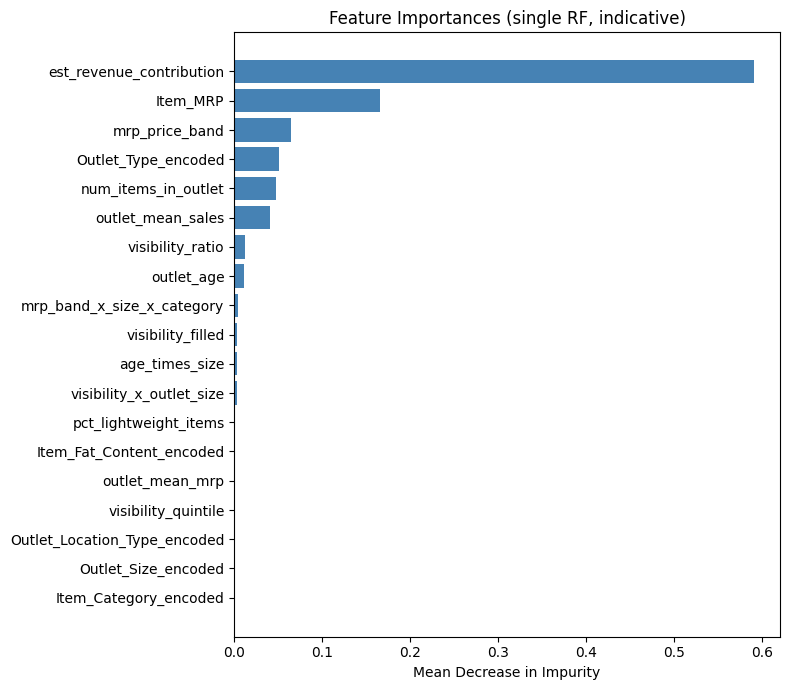

Top 5 features:
                 Feature  Importance
     num_items_in_outlet    0.047298
     Outlet_Type_encoded    0.050444
          mrp_price_band    0.064618
                Item_MRP    0.165186
est_revenue_contribution    0.590682


In [20]:
# Feature importance
quick_model = RandomForestRegressor(
    n_estimators=200,
    min_samples_leaf=75,
    max_features=0.5,
    n_jobs=-1,
    random_state=42
)
quick_model.fit(X_train, y_train)

importance_df = pd.DataFrame({
    'Feature'   : FEATURES,
    'Importance': quick_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 7))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='steelblue')
plt.title('Feature Importances (single RF, indicative)')
plt.xlabel('Mean Decrease in Impurity')
plt.tight_layout()
plt.show()

print('Top 5 features:')
print(importance_df.tail(5)[['Feature', 'Importance']].to_string(index=False))

In [21]:
# --- 5-seed Random Forest ensemble with 5-fold CV ---
# 5 seeds chosen for submission (gives best LB score: 1140.19)
# More seeds can be used for potentially more stable predictions

ENSEMBLE_SEEDS = [42, 7, 13, 99, 2024]

all_oof_predictions  = []
all_test_predictions = []

print(f'Training {len(ENSEMBLE_SEEDS)} seeds × {N_FOLDS} folds = '
      f'{len(ENSEMBLE_SEEDS) * N_FOLDS} models total')
print()

for seed in ENSEMBLE_SEEDS:
    fold_splitter  = KFold(n_splits=N_FOLDS, shuffle=True, random_state=seed)
    oof_preds      = np.zeros(len(X_train))
    test_preds_sum = np.zeros(len(X_test))

    for fold_num, (fold_train_idx, fold_val_idx) in enumerate(
            fold_splitter.split(X_train), start=1):

        fold_model = RandomForestRegressor(
            n_estimators    = 500,
            min_samples_leaf= 75,
            max_features    = 0.5,
            n_jobs          = -1,
            random_state    = seed
        )
        fold_model.fit(X_train[fold_train_idx], y_train[fold_train_idx])

        oof_preds[fold_val_idx]  = fold_model.predict(X_train[fold_val_idx])
        test_preds_sum          += fold_model.predict(X_test) / N_FOLDS

    seed_rmse = np.sqrt(mean_squared_error(y_train, oof_preds))
    print(f'  Seed {seed:4d}  |  OOF RMSE = {seed_rmse:.2f}', flush=True)

    all_oof_predictions.append(oof_preds)
    all_test_predictions.append(test_preds_sum)

# Average across seeds
final_oof_preds  = np.mean(all_oof_predictions,  axis=0)
final_test_preds = np.mean(all_test_predictions, axis=0)

ensemble_rmse = np.sqrt(mean_squared_error(y_train, final_oof_preds))
print()
print(f'5-seed ensemble OOF RMSE : {ensemble_rmse:.2f}')
print(f'Test predictions — mean  : {final_test_preds.mean():.0f}')
print(f'Test predictions — std   : {final_test_preds.std():.0f}')
print(f'Test predictions — min   : {final_test_preds.clip(min=0).min():.0f}')

Training 5 seeds × 5 folds = 25 models total

  Seed   42  |  OOF RMSE = 1073.65
  Seed    7  |  OOF RMSE = 1073.64
  Seed   13  |  OOF RMSE = 1075.49
  Seed   99  |  OOF RMSE = 1074.27
  Seed 2024  |  OOF RMSE = 1074.96

5-seed ensemble OOF RMSE : 1073.56
Test predictions — mean  : 2182
Test predictions — std   : 1323
Test predictions — min   : 134


## 7. Residual Analysis

Inspecting the OOF residuals tells us where the model struggles and 
whether there are any systematic biases.

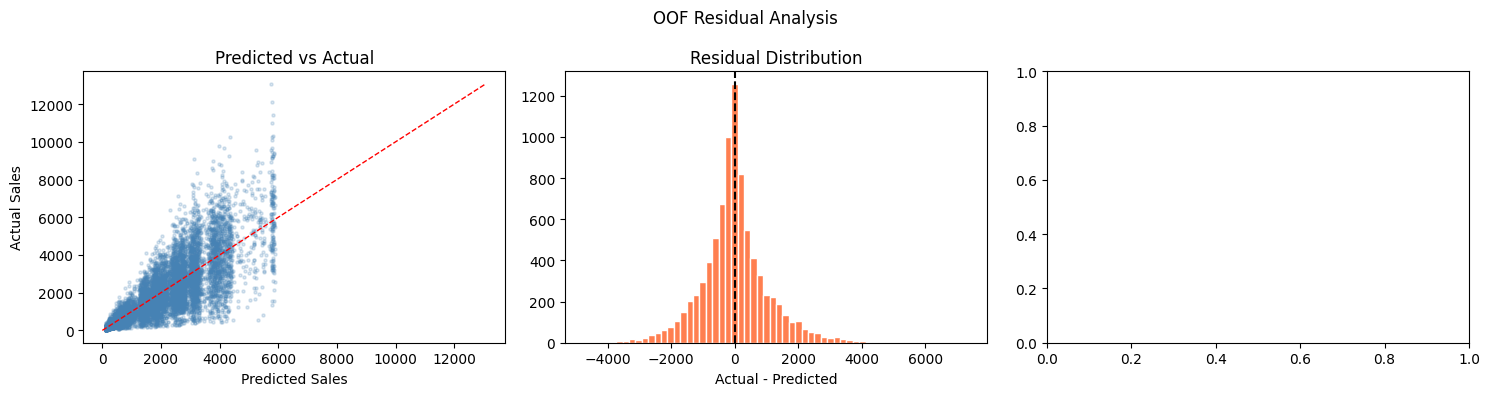

Mean residual  : 0.67  (close to 0 = no systematic bias)
Residual std   : 1073.56
Large errors (>3000): 158 rows


In [22]:
# Residual plot
residuals = y_train - final_oof_preds

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Predicted vs actual
axes[0].scatter(final_oof_preds, y_train, alpha=0.2, s=5, color='steelblue')
max_val = max(final_oof_preds.max(), y_train.max())
axes[0].plot([0, max_val], [0, max_val], 'r--', linewidth=1)
axes[0].set_title('Predicted vs Actual')
axes[0].set_xlabel('Predicted Sales')
axes[0].set_ylabel('Actual Sales')

# Residual distribution
axes[1].hist(residuals, bins=60, color='coral', edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Actual - Predicted')

# # Residuals vs predicted
# axes[2].scatter(final_oof_preds, residuals, alpha=0.2, s=5, color='steelblue')
# axes[2].axhline(0, color='red', linestyle='--')
# axes[2].set_title('Residuals vs Predicted')
# axes[2].set_xlabel('Predicted Sales')
# axes[2].set_ylabel('Residuals')

plt.suptitle('OOF Residual Analysis')
plt.tight_layout()
plt.show()

print(f'Mean residual  : {residuals.mean():.2f}  (close to 0 = no systematic bias)')
print(f'Residual std   : {residuals.std():.2f}')
print(f'Large errors (>3000): {(np.abs(residuals) > 3000).sum()} rows')

## 8. Final Predictions

Convert negative predictions to zero (sales cannot be negative) and save the submission file.

In [23]:
# Generate and save submission
submission = test_df[['Item_Identifier', 'Outlet_Identifier']].copy()
submission['Item_Outlet_Sales'] = final_test_preds.clip(min=0)

output_filename = 'submission/predictions8.csv'
submission.to_csv(output_filename, index=False)

print(f'Submission saved to : {output_filename}')
print(f'Rows                : {len(submission):,}')
print(f'Negative predictions clipped to 0: '
      f'{(final_test_preds < 0).sum()}')
print()
print('Prediction summary:')
print(submission['Item_Outlet_Sales'].describe().round(2))

Submission saved to : submission/predictions8.csv
Rows                : 5,681
Negative predictions clipped to 0: 0

Prediction summary:
count    5681.00
mean     2182.41
std      1323.04
min       134.18
25%      1066.72
50%      2077.16
75%      3103.02
max      5830.95
Name: Item_Outlet_Sales, dtype: float64
